In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # .. from notebooks/
sys.path.insert(0, str(repo_root))      # make the repo importable

import pairs
print(pairs.__file__)


/Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main/pairs/__init__.py


In [2]:
# From notebooks/ → install the package from the repo root (one level up)
%pip install -e "..[notebooks]"  # or just ".." if you didn’t define the [notebooks] extra

Obtaining file:///Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pairs-trading (pyproject.toml) ... done
  Created wheel for pairs-trading: filename=pairs_trading-0.1.0-0.editable-py3-none-any.whl size=9814 sha256=a7bda24d827f14e33645f91f5609728fb2edaf4c2a4c07f5d488ba1bcf5f6b56
  Stored in directory: /private/var/folders/22/xxwj0_711b34fsf64tkzj_ph0000gn/T/pip-ephem-wheel-cache-q2cb7gb8/wheels/f7/54/74/361062dda5fc6aef0e85f34e01e6d28b830dfbe8884dce1e2b
Successfully built pairs-trading
  Attempting uninstall: pairs-trading
    Found existing installation: pairs-trading 0.1.0
    Uninstalling pairs-trading-0.1.0:
      Successfully uninstalled pairs-trading-0.1.0
Note: you may need to restart the 

In [3]:
import sys, importlib.util
print(sys.executable)
print(importlib.util.find_spec("pairs"))
import pairs
print(pairs.__version__)
print(pairs.__file__)

/Users/mengren/opt/anaconda3/envs/stat-arb/bin/python
ModuleSpec(name='pairs', loader=<_frozen_importlib_external.SourceFileLoader object at 0x107116000>, origin='/Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main/pairs/__init__.py', submodule_search_locations=['/Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main/pairs'])
0+unknown
/Users/mengren/Documents/projects/coding_finance/resume_projects/pairs_trading/dynamic-hedge-pairs-trading-main/pairs/__init__.py


# 1. Download historical data using openbb

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# In a notebook under notebooks/
from pairs import load_universe

tickers = load_universe("spx_ndx_combined")  # returns a pandas.Index (UPPERCASE, deduped)
# tickers = load_universe("ndx")
print(len(tickers), tickers[:10].tolist())   # quick peek


517 ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


In [6]:
from pairs import load_prices, download_openbb

In [7]:
start_date="2020-01-01"
end_date="2025-01-01"

# df, failed = download_openbb(tickers, start_date, end_date, return_failed=True)
df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)

# print(df_train.head())
if failed:
    print("No data for:", failed)

ZTS: 100%|██████████| 517/517 [02:04<00:00,  4.16it/s]  


No data for: ['BF.B', 'BRK.B', 'FI', 'IPG', 'K', 'PARA', 'WBA']


In [8]:
df_train

open        high         low       close   volume  \
ticker datetime                                                              
A      2020-01-02   85.900002   86.349998   85.199997   85.949997  1410500   
       2020-01-03   84.669998   85.330002   84.500000   84.570000  1118300   
       2020-01-06   84.000000   84.820000   83.599998   84.820000  1993200   
       2020-01-07   83.959999   85.260002   83.940002   85.080002  1684700   
       2020-01-08   85.959999   86.470001   85.199997   85.919998  1847600   
...                       ...         ...         ...         ...      ...   
ZTS    2024-12-24  163.699997  165.039993  162.740005  164.699997  1023600   
       2024-12-26  163.720001  165.789993  163.020004  165.520004  2167200   
       2024-12-27  164.949997  166.529999  163.520004  164.600006  1800100   
       2024-12-30  163.889999  164.050003  161.449997  162.240005  1531400   
       2024-12-31  162.899994  163.750000  161.869995  162.929993  1327400   

                   dividend  split_ratio  
ticker datetime                           
A      2020-01-02       0.0          NaN  
       2020-01-03       0.0          NaN  
       2020-01-06       0.0          NaN  
       2020-01-07       0.0          NaN  
       2020-01-08       0.0          NaN  
...                     ...          ...  
ZTS    2024-12-24       0.0          NaN  
       2024-12-26       0.0          NaN  
       2024-12-27       0.0          NaN  
       2024-12-30       0.0          NaN  
       2024-12-31       0.0          NaN  

[633321 rows x 7 columns]

## 1.1 Pre-filter for Data Quality

We keep tickers whose coverage matches the global coverage

In [9]:
import pandas as pd

# infer level names/positions
lvl_names = list(df_train.index.names)
ticker_lvl = 0                                  # you said ticker is first level
time_lvl_name = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

# global time span
full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

# per-ticker start/end
starts = df_train.groupby(level=ticker_lvl).apply(
    lambda g: g.index.get_level_values(time_lvl_name).min()
)
ends = df_train.groupby(level=ticker_lvl).apply(
    lambda g: g.index.get_level_values(time_lvl_name).max()
)

# tickers whose coverage matches the global coverage
tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index

# filter df by those tickers
df_filtered = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

The original number of tickers, *vs.* the number of tickers matching the global coverage

In [10]:
len(df_train.index.get_level_values('ticker').unique()), len(df_filtered.index.get_level_values('ticker').unique())

(510, 494)

Below is the set of tickers whose time coverages are shorter than the global coverage

In [11]:
set(tickers) - set(df_filtered.index.get_level_values('ticker').unique())

{'ABNB',
 'APP',
 'ARM',
 'BF.B',
 'BRK.B',
 'CARR',
 'CEG',
 'COIN',
 'DASH',
 'EXE',
 'FI',
 'GEHC',
 'GEV',
 'GFS',
 'IPG',
 'K',
 'KVUE',
 'OTIS',
 'PARA',
 'PLTR',
 'SOLV',
 'VLTO',
 'WBA'}

# 2. Cointegration Screening

## 2.1 Initial Cointegration Screening

Here, we implement the following two cointegration tests
- Engle-Granger test, and
- Johansen test

In [12]:
from pairs import find_cointegrated_pairs_dualgate

summary_dual = find_cointegrated_pairs_dualgate(
    df_filtered,
    alpha_eg=0.05, eg_trend="c",
    alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
    n_workers=16, chunksize=8, show_progress=True
)

In [13]:
summary_dual.sample(20)

,,eg_t,eg_p,eg_p_fdr,eg_pass,joh_stat,joh_pass,verdict
ticker1,ticker2,,,,,,,
CL,GOOG,-3.021558,0.105170,0.767541,False,8.698623,False,fail
FITB,OXY,-1.456776,0.777391,0.997659,False,7.129513,False,fail
PGR,UAL,-2.399719,0.324988,0.928076,False,21.298730,True,fail
LULU,MCHP,-2.570484,0.248898,0.888658,False,16.756222,True,fail
MCHP,PEG,-1.971682,0.543263,0.965565,False,10.816299,False,fail
AVB,ZS,-2.739123,0.185824,0.852253,False,19.243490,True,fail
TGT,TMO,-1.672275,0.689444,0.992485,False,10.966420,False,fail
DDOG,EG,-2.583947,0.243351,0.885601,False,8.778711,False,fail
GRMN,HPQ,-0.267749,0.977312,1.000000,False,6.698214,False,fail


In [14]:
# summary_dual is what find_cointegrated_pairs_dualgate returns
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
# normalize to [0,1] and average
tmp["pre_score"] = 0.5*(tmp["rank_eg"]/tmp["rank_eg"].max()
                      + tmp["rank_joh"]/tmp["rank_joh"].max())
prelim = tmp.sort_values("pre_score", ascending=True)   # lower rank is better
# pick top N (e.g., 2–3× the number you intend to trade)
candidates = prelim.head(200).index.to_list()

## 2.1.1 Multiple Testing Correction (Benjamini-Hochberg FDR)

### Why it matters

We just tested **121,771 pairs** simultaneously at α = 0.05.  
By chance alone, we expect ~6,089 false positives even if *no pair* is truly cointegrated.

The **Benjamini-Hochberg (BH)** procedure controls the *False Discovery Rate* (FDR) — the expected fraction of declared discoveries that are false — at level α, which is much less conservative than Bonferroni while still being meaningful.

The new `eg_p_fdr` column in `summary_dual` contains the BH-adjusted p-value for each pair.  
`find_cointegrated_pairs_dualgate` already runs BH by default (`fdr_method="bh"`), but we can also apply it post-hoc to the existing `summary_dual` for transparency.

In [15]:
import numpy as np
from pairs.stats.cointegration import benjamini_hochberg_fdr

# ── Post-hoc BH correction on summary_dual ──────────────────────────────────
alpha_fdr = 0.05
raw_pvals = summary_dual["eg_p"].values

reject_bh, padj = benjamini_hochberg_fdr(raw_pvals, alpha=alpha_fdr)

summary_dual_fdr = summary_dual.copy()
summary_dual_fdr["eg_p_fdr"] = padj
summary_dual_fdr["eg_pass_fdr"] = reject_bh   # BH-corrected gate

n_raw   = int((raw_pvals <= alpha_fdr).sum())
n_fdr   = int(reject_bh.sum())
n_tests = len(raw_pvals)

print(f"Total pairs tested        : {n_tests:>8,}")
print(f"Expected false positives  : {n_tests * alpha_fdr:>8,.0f}  (= {n_tests} × {alpha_fdr})")
print(f"Raw EG significant (p≤.05): {n_raw:>8,}")
print(f"After BH correction       : {n_fdr:>8,}  ({n_raw - n_fdr:+d} removed)")
print()
print("Head of BH-corrected EG results (sorted by adj p-value):")
summary_dual_fdr[summary_dual_fdr["eg_pass_fdr"]].sort_values("eg_p_fdr").head(10)[
    ["eg_t", "eg_p", "eg_p_fdr", "eg_pass_fdr", "joh_pass", "verdict"]
]

Total pairs tested        :  121,771
Expected false positives  :    6,089  (= 121771 × 0.05)
Raw EG significant (p≤.05):    9,140
After BH correction       :      304  (+8836 removed)

Head of BH-corrected EG results (sorted by adj p-value):


eg_t          eg_p  eg_p_fdr  eg_pass_fdr  joh_pass  \
ticker1 ticker2                                                            
CCL     SHOP    -6.470849  1.466481e-07  0.005995         True      True   
NCLH    SHOP    -6.510805  1.189120e-07  0.005995         True      True   
        TTWO    -6.371451  2.461515e-07  0.005995         True      True   
        XYZ     -6.468029  1.488290e-07  0.005995         True      True   
        ZBRA    -6.410423  2.010411e-07  0.005995         True      True   
CCL     TTWO    -6.250168  4.597262e-07  0.006401         True      True   
NCLH    PNC     -6.230421  5.085499e-07  0.006401         True      True   
        TRMB    -6.266599  4.226243e-07  0.006401         True      True   
        TROW    -6.223924  5.256942e-07  0.006401         True      True   
        WDAY    -6.298250  3.592284e-07  0.006401         True      True   

                verdict  
ticker1 ticker2          
CCL     SHOP       pass  
NCLH    SHOP       pass  
        TTWO       pass  
        XYZ        pass  
        ZBRA       pass  
CCL     TTWO       pass  
NCLH    PNC        pass  
        TRMB       pass  
        TROW       pass  
        WDAY       pass

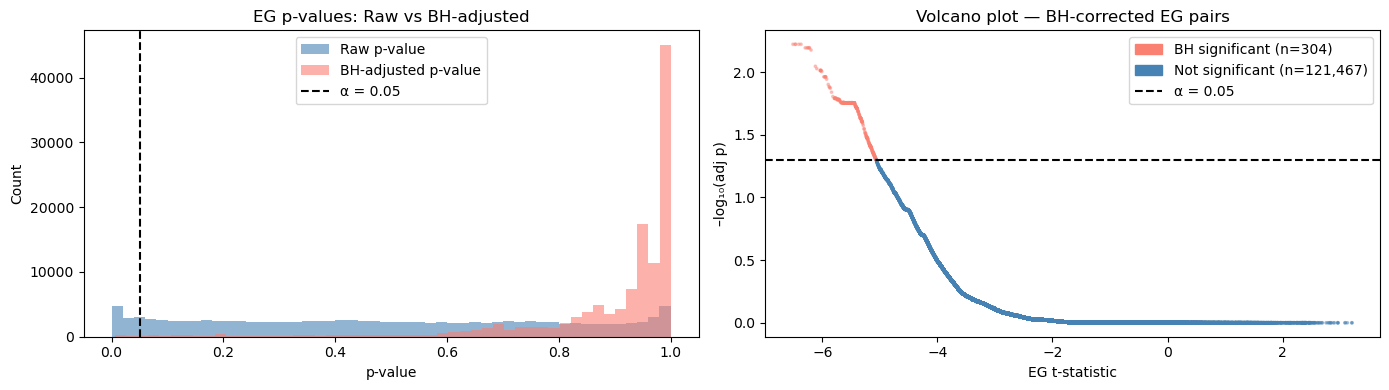


Conclusion: BH removes 8,836 of 9,140 raw-significant pairs, keeping 304 with controlled FDR ≤ 5%.


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: histogram of raw vs BH-adjusted p-values ──────────────────────────
ax = axes[0]
ax.hist(raw_pvals, bins=50, alpha=0.6, label="Raw p-value", color="steelblue")
ax.hist(padj, bins=50, alpha=0.6, label="BH-adjusted p-value", color="salmon")
ax.axvline(alpha_fdr, color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("p-value")
ax.set_ylabel("Count")
ax.set_title("EG p-values: Raw vs BH-adjusted")
ax.legend()

# ── Right: volcano-style scatter (t-stat vs –log10 adj p) ───────────────────
ax = axes[1]
log_padj = -np.log10(np.clip(padj, 1e-300, 1.0))
colours = np.where(reject_bh, "salmon", "steelblue")
ax.scatter(summary_dual["eg_t"].values, log_padj, c=colours, s=3, alpha=0.4)
ax.axhline(-np.log10(alpha_fdr), color="black", linestyle="--", lw=1.5,
           label=f"BH threshold (α={alpha_fdr})")
ax.set_xlabel("EG t-statistic")
ax.set_ylabel("–log₁₀(adj p)")
ax.set_title("Volcano plot — BH-corrected EG pairs")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="salmon", label=f"BH significant (n={n_fdr:,})"),
    Patch(color="steelblue", label=f"Not significant (n={n_tests - n_fdr:,})"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"α = {alpha_fdr}"),
])

plt.tight_layout()
plt.show()
print(f"\nConclusion: BH removes {n_raw - n_fdr:,} of {n_raw:,} raw-significant pairs, "
      f"keeping {n_fdr:,} with controlled FDR ≤ {alpha_fdr:.0%}.")

In [17]:
prelim

eg_t          eg_p  eg_p_fdr  eg_pass   joh_stat  \
ticker1 ticker2                                                         
CCL     TTWO    -6.250168  4.597262e-07  0.006401     True  42.250921   
NCLH    TTWO    -6.371451  2.461515e-07  0.005995     True  39.980485   
        NSC     -6.121224  8.850157e-07  0.008981     True  38.021322   
        TRMB    -6.266599  4.226243e-07  0.006401     True  37.178857   
CCL     SHOP    -6.470849  1.466481e-07  0.005995     True  36.676596   
...                   ...           ...       ...      ...        ...   
AVGO    MPC      0.806872  9.938628e-01  1.000000    False   2.467877   
AXP     OXY      0.582827  9.931300e-01  1.000000    False   1.660159   
AVGO    COP      1.076664  1.000000e+00  1.000000    False   2.797799   
AMP     DVN      0.945155  1.000000e+00  1.000000    False   2.757229   
KKR     OXY      0.944967  1.000000e+00  1.000000    False   2.508216   

                 joh_pass verdict   rank_eg  rank_joh  pre_score  
ticker1 ticker2                                                   
CCL     TTWO         True    pass       8.0      13.0   0.000086  
NCLH    TTWO         True    pass       5.0      23.0   0.000115  
        NSC          True    pass      12.0      40.0   0.000214  
        TRMB         True    pass       7.0      52.0   0.000242  
CCL     SHOP         True    pass       2.0      61.0   0.000259  
...                   ...     ...       ...       ...        ...  
AVGO    MPC         False    fail  120625.0  121305.0   0.995345  
AXP     OXY         False    fail  120208.0  121727.0   0.995359  
AVGO    COP         False    fail  121290.0  120810.0   0.996054  
AMP     DVN         False    fail  121290.0  120890.0   0.996383  
KKR     OXY         False    fail  121290.0  121255.0   0.997881  

[121771 rows x 10 columns]

In [18]:
candidates

[('CCL', 'TTWO'),
 ('NCLH', 'TTWO'),
 ('NCLH', 'NSC'),
 ('NCLH', 'TRMB'),
 ('CCL', 'SHOP'),
 ('NCLH', 'WDAY'),
 ('NCLH', 'PDD'),
 ('NCLH', 'TER'),
 ('NCLH', 'TXN'),
 ('NCLH', 'SBUX'),
 ('NCLH', 'SHOP'),
 ('ABT', 'NSC'),
 ('CCL', 'EBAY'),
 ('NCLH', 'UDR'),
 ('NCLH', 'TDY'),
 ('CCL', 'COO'),
 ('NCLH', 'ZS'),
 ('NCLH', 'SW'),
 ('CCL', 'TRMB'),
 ('CCL', 'MELI'),
 ('NCLH', 'PPG'),
 ('NCLH', 'ZBRA'),
 ('NCLH', 'WEC'),
 ('CCL', 'ECL'),
 ('NCLH', 'ROK'),
 ('CCL', 'EA'),
 ('CCL', 'CTSH'),
 ('NCLH', 'TROW'),
 ('CCL', 'FDX'),
 ('NCLH', 'STT'),
 ('CCL', 'TYL'),
 ('NCLH', 'PNW'),
 ('NCLH', 'TEL'),
 ('NCLH', 'NWSA'),
 ('NCLH', 'VRSN'),
 ('CCL', 'TER'),
 ('GM', 'SW'),
 ('NCLH', 'TEAM'),
 ('CCL', 'WDAY'),
 ('NCLH', 'XYZ'),
 ('CCL', 'GM'),
 ('NCLH', 'UNP'),
 ('NCLH', 'NDSN'),
 ('NCLH', 'PODD'),
 ('NCLH', 'TTD'),
 ('CCL', 'PDD'),
 ('CCL', 'EMN'),
 ('CCL', 'EXPE'),
 ('MA', 'PH'),
 ('NCLH', 'XEL'),
 ('NCLH', 'TYL'),
 ('CCL', 'SW'),
 ('RCL', 'WMT'),
 ('NCLH', 'POOL'),
 ('ABT', 'EMN'),
 ('CCL', 'ZBRA'),
 ('

## 2.2 Kalman Filtering and Stationarity Tests on Residuals

In [19]:
from pairs import (
    fit_kalman_hedge,
    summarize_spread_stationarity_joblib,
)

### Overview: Dynamic Hedge via Kalman Filter

We model a time-varying hedge ratio between two assets with a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = 
\begin{bmatrix}
\beta_t \\ \alpha_t
\end{bmatrix},
\qquad
\theta_t = \theta_{t-1} + w_t
$$
where $w_t\sim\mathcal{N}(0, Q)$.

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t,
\qquad
v_t\sim\mathcal{N}(0, R).
$$

**Calibration:**
Expectation-Maximization (EM) can learn $Q$ (state noise) and $R$ (observation noise).



### Terminology

- **In-sample calibration** (often called "training"): learn $Q$, $R$ with EM and estiamte $(\alpha_t, \beta_t)$ on the train window.
- **Out-of-sample continuation**: continue **filtering** on the test window using the **last train state and learng $Q, R$.

Here, we perform in-sample calibration of a Kalman filter in the cell below.

In [20]:
# in-sample calibration of a Kalman filter
states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="smooth",
    em_iters=5,          # modest EM to learn Q/R
    q=1e-5,              # slow drift
    n_workers=None,      # all CPUs
    chunksize=100,
    show_progress=True,
    return_params=True,  # ← get (states, params)
)

In [21]:
summary_stationarity = summarize_spread_stationarity_joblib(states_tr, alpha=0.05, regression="c", 
                                                            chunksize=256, show_progress=True)

In [22]:
summary_stationarity

adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
BDX     EQIX    -12.828787  5.934722e-24   0.500000  0.041667       NaN   
NCLH    ZBH     -12.473892  3.199924e-23   0.500000  0.041667       NaN   
        SJM     -11.099367  3.900222e-20   0.500000  0.041667       NaN   
CCL     TTD     -19.525296  0.000000e+00   0.020837  0.100000  0.392928   
        MCHP    -19.649572  0.000000e+00   0.024471  0.100000  0.285805   
...                    ...           ...        ...       ...       ...   
        PDD      -9.116330  3.294847e-15   0.011479  0.100000  0.396556   
BDX     CTRA     -9.074910  4.204632e-15   0.011265  0.100000  3.285298   
NCLH    PCG      -8.306867  3.882491e-13   0.146623  0.100000  3.933575   
BDX     T        -8.229537  6.115817e-13   0.010770  0.100000  2.723990   
        F        -7.620286  2.137450e-11   0.018754  0.100000  8.127352   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
BDX     EQIX        0.518092 -0.007085  inconclusive  
NCLH    ZBH         0.297638 -0.013054  inconclusive  
        SJM         0.293810 -0.025110  inconclusive  
CCL     TTD         0.432388 -0.075810    stationary  
        MCHP        0.387723 -0.033276    stationary  
...                      ...       ...           ...  
        PDD         0.384300 -0.025340    stationary  
BDX     CTRA        4.601901 -0.009920    stationary  
NCLH    PCG         1.818576 -0.259086    stationary  
BDX     T           4.226495  0.002390    stationary  
        F           7.087675 -0.027288    stationary  

[200 rows x 8 columns]

### Stationarity Test

The test runs, on each pair:
1. **ADF (Augmented Dickey-Fuller)** on the residual series $\varepsilon_t$ (aka spread, contained in states_tr from the cell above)
- adfuller (s, autolag="AIC", regression=regression)
- Returns adf_stat, adf_p, plus lags/crit (lags/crit not kept in the summary frame).
2. **KPSS** on the same series
- kpss(s, regression=("c" if regression=="c" else "ct"), nlags="auto")
- Returns kpss_stat, kpss_p.

**Verdict rule** (using alpha, default 0.05):
- If **ADF rejects** ($p<\alpha$) **and KPSS does not reject** ($p\geq\alpha$) $\to$ "stationary"
- If **ADF does not reject and KPSS rejects** $\to$ "non-stationary"
- Otherwise $\to$ "inconclusive"

**Extra diagnostics it computes**
- **Half-life** (quick AR-style proxy for mean reversion speed): Fits a slope on ($\varepsilon_{t-1}$ and $\Delta\varepsilon_t$, from the residual series) with np.polyfit and uses
$$
\mathrm{halflife} \approx -\frac{\ln 2}{\beta}
$$
(returns np.nan if unstable or slope is 0).

Here, $\varepsilon_{t-1}$ is the **previous-period residual**. In our setup,
$$
\varepsilon_t = P^{(1)}_t - (\alpha_t + \beta_t P^{(2)}_t),
$$
where $P^{(1)}$ and $P^{(2)}$ are the two price series

- **Residual sigma**: s.std() on the residual series $\varepsilon_t$. 

### Composite scoring to rank tradable pairs

The following cell takes the stationarity diagnostics and creates a **single composite score** per pair to rank candidates for trading. The idea is to convert heterogeneous metrics (p-values, half-life, residual scale, Sharpe) into comparable **z-scores**, align their direction (higher = better), and sum them with optional weights.

#### 1) Inputs and safeguards
- Start from summary_stationarity (ADF/KPSS results, half-life, standard deviation of residual series $\varepsilon_t$, optional sharpe_train) and copy to final_df.
- Coerce relevant columns to numeric to avoid dtype surprises.
- Provide a safe fallback for sharpe_train (zeros if the column is missing).
- **Clip** extreme values to keep transforms well-behaved:
    - adf_p, kpss_p are clipped to $[10^{-300}, 1]$ so $-\log_{10}(p)$ never hits infinity.
    - halflife is clipped at 0 so np.log1p(halflife) is defined (the function np.log1p(x) computes np.log(1+x) but is numerically more accurate).

#### 2) Turn each metric into a "higher is better" score

For a series $s$, the z-score is 
$$
Z(s) = \frac{s-\bar{s}}{\mathrm{std}(s)}.
$$
We apply monotone transforms so that **desirable properties map to larger numbers** before z-scoring:
- **ADF**: smaller $p$ is better $\longrightarrow$ use $-\log_{10}(p_{\mathrm{ADF}})$ then $Z(\cdot)$
- **KPSS**: larger $p$ is better $\longrightarrow$ use $Z(p_{\mathrm{KPSS}})$.
- **Half-life**: shorter is better $\longrightarrow$ use $-\log(1+\textrm{half-life})$ then $Z(\cdot)$
- **Residual sigma** (spread volatility): lower is better $\longrightarrow$ use $-\sigma_{\varepsilon_t}$ then $Z(\cdot)$
- **Sharpe (train)**: higher is better $\longrightarrow$ use $Z(\textrm{Sharpe})$ (or zeros if missing)

Each component is standardized independently, making the scales comparable even if raw units differ.

#### 3) Optional weighting

A weights dict (default all 1.0) lets you emphasize particular aspects:
- e.g., put more weight on **half-life** for faster mean-reverters, or on **ADF** for stronger stationarity evidence.

The composite score is the **weighted sum** of component z-scores:
$$
\mathrm{score} = \sum_k w_k Z_k.
$$

#### 4) Optional out-of-sample (OOS) sanity filter

If validation-window $p$-value exist (adf_p_val, kpss_p_val), filter to pairs that remain stationary OOS:
- keep pairs with $\text{adf\_p\_val}<0.05$ **and** $\text{adf\_p\_val}<0.10$.

#### 5) Ranking

Sort final_df by score (descending) to get ranked, our prioritized list of pairs.

#### Why these choices?
- **Z-scores** make heterogeneous signals comparable and robust to unit differences.
- **Monotone transforms** align the directionality (all components "higher is better").
- **Clipping** avoids degenerate values (e.g., $p=$ due to underflow).
- **Log transforms** tame long right tails (half-life) and stabilize contributions.
- **OOS filter**  guards against in-sample overfitting when you have a held-out window.

In [23]:
# Imports (once per notebook)
import numpy as np
import pandas as pd
from pairs.stats import Z, zscore  # Z is your back-compat alias

final_df = summary_stationarity.copy()

# Ensure numeric dtypes where needed
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# Safe Series fallback for sharpe_train
sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))

# Stabilize p-values and halflife before transforms
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)      # avoid -log10(0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)                    # no negative half-lives

# Build component scores (higher is better for each)
components = {
    "adf":   Z(-np.log10(p_adf)),        # smaller p → larger score
    "kpss":  Z(p_kpss),                  # larger p → larger score
    "hl":    Z(-np.log1p(hl_safe)),      # shorter half-life → larger score
    "sigma": Z(-final_df["resid_sigma"]),# lower residual sigma → larger score
    "sharpe": Z(sharpe_series),          # optional Sharpe (0 if missing)
}

# Optional weights per component (tune as you like)
weights = {"adf":1.0, "kpss":1.0, "hl":1.0, "sigma":1.0, "sharpe":1.0}

# Weighted sum into a single composite score
final_df["score"] = sum(weights[k] * components[k] for k in components)

# Rank by score
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)


adf_stat         adf_p  kpss_stat  kpss_p  halflife  \
ticker1 ticker2                                                         
CCL     MCHP    -19.649572  0.000000e+00   0.024471     0.1  0.285805   
        TTD     -19.525296  0.000000e+00   0.020837     0.1  0.392928   
        EXPE    -17.137371  7.082809e-30   0.145505     0.1  0.144025   
        MU      -17.815031  3.177835e-30   0.025999     0.1  0.189466   
NCLH    O       -12.634134  1.482672e-23   0.067105     0.1  0.085913   
CCL     EQR     -12.796286  6.904890e-24   0.036655     0.1  0.137612   
NCLH    WST     -10.995491  6.888202e-20   0.020122     0.1  0.127871   
CCL     TER     -11.143501  3.066520e-20   0.024081     0.1  0.145079   
        EVRG    -11.495748  4.618915e-21   0.064321     0.1  0.146007   
        EBAY    -15.823954  1.012478e-28   0.027662     0.1  0.253381   

                 resid_sigma    shapre     verdict      score  
ticker1 ticker2                                                
CCL     MCHP        0.387723 -0.033276  stationary  10.775544  
        TTD         0.432388 -0.075810  stationary  10.502346  
        EXPE        0.278307 -0.019983  stationary   1.517802  
        MU          0.352356 -0.036969  stationary   1.346601  
NCLH    O           0.383001 -0.044662  stationary   1.339785  
CCL     EQR         0.325232 -0.045157  stationary   1.274014  
NCLH    WST         0.314196 -0.022364  stationary   1.166209  
CCL     TER         0.306239 -0.017058  stationary   1.143000  
        EVRG        0.338763 -0.041509  stationary   1.138596  
        EBAY        0.369410 -0.029782  stationary   1.125860

- Kalman filtering allows us to obtain the residual series for each pair.
- Several measures of stationarity of the residual series have been computed above.
- A score has been computed for each pair, which takes the stationarity diagnostics and creates a **single composite score** per pair to rank candidates for trading. The score converts heterogeneous metrics (p-values, half-life, residual scale, Sharpe) into comparable **z-scores**, thus aligning their direction (higher = better).
- We select robust pairs based on a plot of the score. The cutoff is set at the elbow of the curve.

<Axes: xlabel='ticker1,ticker2'>

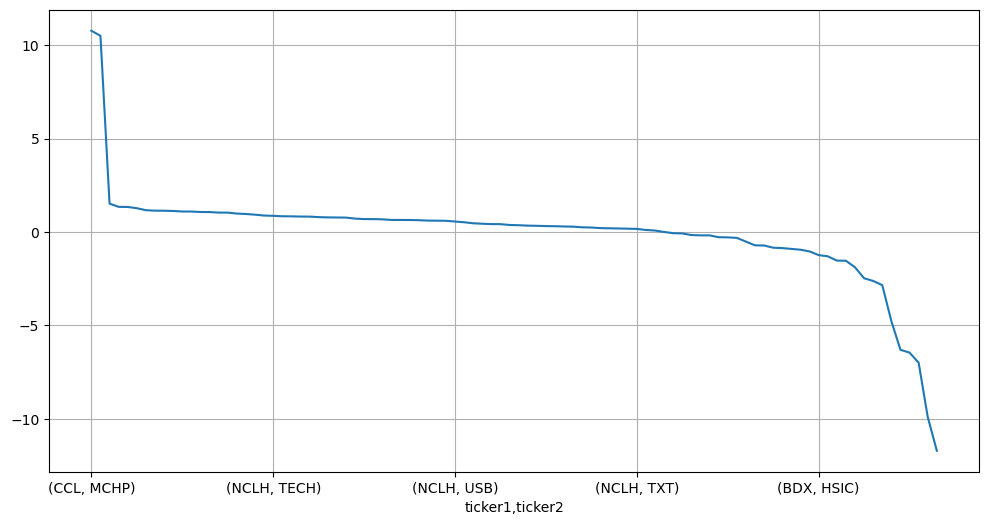

In [24]:
ranked['score'].plot(figsize=(12, 6), grid=True)

From the figure above, the elbow of the curve can be estimated to be around -3.

In [25]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs = ranked_positive.index

In [26]:
len(candidates), len(robust_pairs)

(200, 88)

#### Select a pair from among the ones meeting the threshold

In [27]:
import random
(ticker1, ticker2) = robust_pairs[random.randint(0, len(ranked_positive)-1)]
# (ticker1, ticker2) = robust_pairs[0]
print('Pairs:', ticker1, ticker2)

Pairs: NCLH TRMB


# 3. Generate Trading Signals

## 3.1  Extract Kalmal filter states for the selected pair & reshape prices to wide format

- df_kf = states_tr[(ticker1, ticker2)]

    Pull the Kalman output for the chosen pair from the training window.

    This DataFrame has time index and columns such as:
    - alpha, beta - time-varying intercept and hedge ratio
    - y_hat - fitted $\hat{y}_t=\alpha_t+\beta_t x_t$
    - resid - residual (aka spread) $\varepsilon_t = y_t - \hat{y}_t$

- prices = df_filtered.pivot_table(...)
    Convert the long, MultiIndex prices into a wide matrix:
        - Index: datetime
        - Columns: ticker
        - Values: close

    This makes it easy to access leg prices side-by-side, e.g. prices[[ticker1, ticker2]], and to join them with df_kf for signal generation or hedged-return calculations.

In [28]:
df_kf = states_tr[(ticker1, ticker2)]
prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'), 
    columns=df_filtered.index.get_level_values('ticker'), values='close'
)

## Build a pair-aligned frame: leg prices + Kalman fields

This cell constructs a **single DataFrame** with the two leg prices and the key Kalman outputs:

- P1 / P2: spot prices for ticker1 and ticker2 pulled from the wide prices matrix.
- beta / resid: time-varying hedge ratio and residual (spread) from df_kf.

In [29]:
df_pair = pd.DataFrame({
    'P1': prices[ticker1],
    'P2': prices[ticker2]
}).join(df_kf[['beta', 'resid']])

## 3.2 Generate trading signals

In [30]:
from pairs.strategies import generate_pair_signals

signals = generate_pair_signals(
    df_pair,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,            # set like 3*estimate_halflife(df_pair['resid'])
    cooldown_bars=0
)

In [31]:
signals

,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2020-01-02,NaN,0,0.0,0.0,False,False,False
2020-01-03,NaN,0,0.0,0.0,False,False,False
2020-01-06,NaN,0,0.0,0.0,False,False,False
2020-01-07,NaN,0,0.0,0.0,False,False,False
2020-01-08,NaN,0,0.0,0.0,False,False,False
...,...,...,...,...,...,...,...
2024-12-24,0.525695,0,0.0,0.0,False,True,False
2024-12-26,-0.242216,0,0.0,0.0,False,False,False
2024-12-27,-0.428088,0,0.0,0.0,False,False,False


# 3.3 Visualize trading signals and compute performance metrics of strategy on training data

### 3.3.1 Plot trading signals

In [32]:
from pairs import plot_pair_legs_with_trades

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • NCLH (top), TRMB (bottom)'}, ylabel='Price'>))

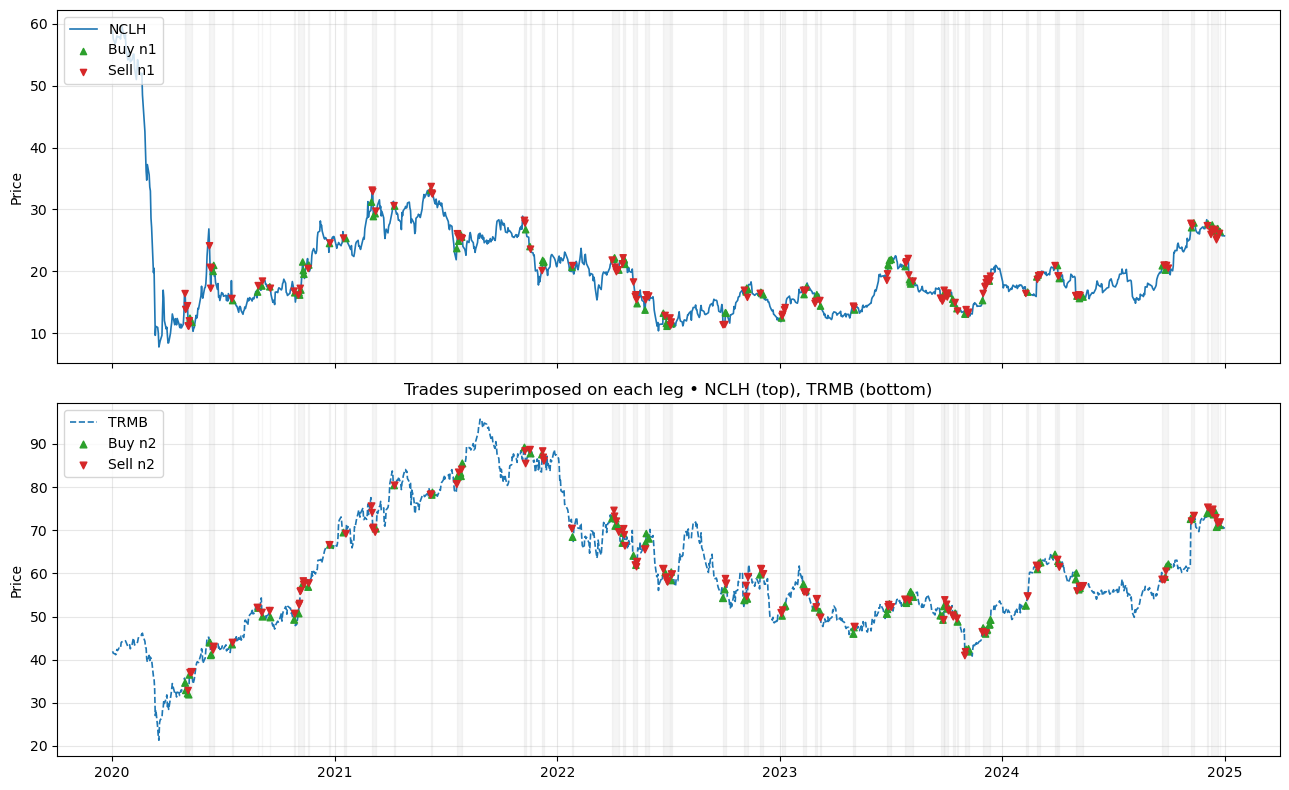

In [33]:
# df_pair: has P1,P2 columns (and optionally beta,y_hat)
# signals: from generate_pair_signals(...), has z,pos,n1,n2,entry,exit,stop

plot_pair_legs_with_trades(
    df_pair, signals,
    label1=ticker1, label2=ticker2,
    normalize=False, # base_value=100,
    shade_positions=True,
    size_scale=0.004,   # tweak to taste based on your notional levels
    min_marker=20, max_marker=220
)


### 3.3.2 Compute performance metrics of strategy on training data

In [34]:
from pairs import evaluate_pair_signals

In [35]:
# df_pair has P1,P2; signals are your executed outputs (with next-bar logic)
daily, trades, summary = evaluate_pair_signals(
    df_pair, signals,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50,
    days_per_year=252,          # borrow accrual basis
    bars_per_year=252       # 390*252 for 1-min RTH scaling
)


print(pd.Series(summary))
# daily[['pnl_net','equity','drawdown_pct']].tail()
# trades.head()

start                       2020-01-02 00:00:00
end                         2024-12-31 00:00:00
bars                                       1258
capital_base                       10015.719339
gross_pnl                          15386.028954
net_pnl                            15264.408933
ann_return                             0.340207
sharpe                                 1.933512
max_drawdown                        1106.273763
max_drawdown_pct                       0.059146
avg_gross_exposure                  1375.190853
avg_exposure_utilization               0.998425
turnover_annualized                   21.041232
n_trades                                     51
hit_rate                               0.921569
avg_win                               339.87221
avg_loss                            -164.643542
profit_factor                         24.255421
avg_hold_bars                          3.392157
med_hold_bars                               3.0
ann_vol                                0

# 4. Evaulate Strategy performance on out-of-sample data

## 4.1 Download or import data for the **selected pair**

In [36]:
start_test="2025-01-02"
end_test="2025-08-15"

In [37]:
df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)

print(df_test.head())
if failed:
    print("No data for:", failed)

TRMB: 100%|██████████| 2/2 [00:00<00:00, 11.88it/s]

                    open       high        low      close   volume
ticker datetime                                                   
NCLH   2025-01-02  26.18  26.299999  25.620001  25.920000  8529800
       2025-01-03  25.85  25.990000  24.709999  25.420000  9514800
       2025-01-06  25.75  26.150000  25.350000  25.639999  9244100
       2025-01-07  25.58  25.620001  24.480000  25.510000  9142200
       2025-01-08  25.25  26.040001  25.030001  25.920000  7218800


## 4.2 Continue the Kalman filter on out-of-sample (OOS) data

Use the parameters learned on the training window to *continue* the Kalman filter on the test window, producing OOS paths for $\alpha_t$, $\beta_t$, $\hat{y}_t$ and the residual $\varepsilon_t$ **without** look-ahead.

**What we freeze from training (per pair):**
- State transition $F$, process noise $Q$, observation noise $R$ - from params_tr.
- The **last filtered** state at train end: last_state_mean, last_state_cos.

    This carries information into the test window and avoids a diffuse restart.

In [38]:
# pick the pair you trained
pair = (ticker1, ticker2)

# freeze hyperparameters learned on TRAIN
frozen = {
    "F": params_tr[pair]["F"],
    "Q": params_tr[pair]["Q"],
    "R": params_tr[pair]["R"],
}

# start the new run from the last *filtered* TRAIN state (or use None for diffuse)
last_state = (params_tr[pair]["last_state_mean"], params_tr[pair]["last_state_cov"])

# make sure P1_new, P2_new are aligned and share the same DateTimeIndex
P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']

from pairs import filter_kf_on_new

states_te, last_state_te = filter_kf_on_new(
    P1_new, P2_new,
    frozen=frozen,
    last_state=last_state,   # use None to restart diffusely if you *must*
    init_cov=1e6,
    mode="filter"            # "filter" for OOS; "smooth" only for post-hoc analysis
)


#### Join test states with test prices to prepare signals/evaluation:

In [39]:
prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close"
)
df_pair_te = states_te.join(
    prices_te[[ticker1, ticker2]].rename(columns={ticker1:"P1", ticker2:"P2"}),
    how="inner"
)

#### Generate trading signals on out-of-sample (OOS) data

In [40]:
from pairs.strategies import generate_pair_signals

signals_te = generate_pair_signals(
    df_pair_te,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,            # set like 3*estimate_halflife(df_pair['resid'])
    cooldown_bars=0
)

## 4.3 Plot trading signals on out-of-sample data

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • NCLH (top), TRMB (bottom)'}, ylabel='Price'>))

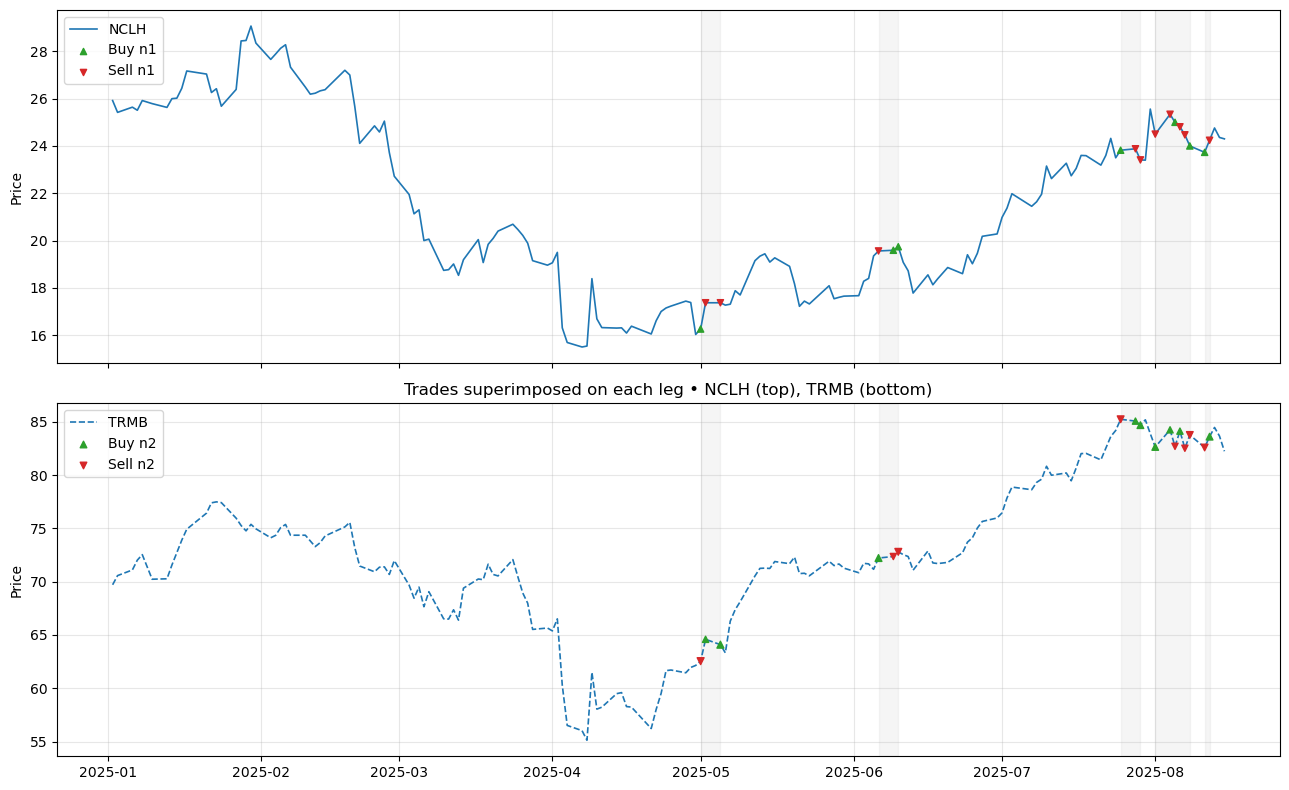

In [41]:
plot_pair_legs_with_trades(
    df_pair_te, signals_te,
    label1=ticker1, label2=ticker2,
    normalize=False, # base_value=100,
    shade_positions=True,
    size_scale=0.004,   # tweak to taste based on your notional levels
    min_marker=20, max_marker=220
)

## 4.4 Evaluate strategy performance on out-of-sample data

In [42]:
# df_pair has P1,P2; signals are your executed outputs (with next-bar logic)
daily, trades, summary = evaluate_pair_signals(
    df_pair_te, signals_te,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50,
    days_per_year=252,          # borrow accrual basis
    bars_per_year=252       # 390*252 for 1-min RTH scaling
)


print(pd.Series(summary))
# daily[['pnl_net','equity','drawdown_pct']].tail()
# trades.head()

start                       2025-01-02 00:00:00
end                         2025-08-15 00:00:00
bars                                        155
capital_base                        10041.94682
gross_pnl                            270.610861
net_pnl                                259.2997
ann_return                              0.04253
sharpe                                 1.636223
max_drawdown                          82.464628
max_drawdown_pct                       0.008027
avg_gross_exposure                   777.044996
avg_exposure_utilization               0.999491
turnover_annualized                   16.409089
n_trades                                      5
hit_rate                                    1.0
avg_win                               52.865186
avg_loss                                    0.0
profit_factor                               inf
avg_hold_bars                               2.4
med_hold_bars                               2.0
ann_vol                                0

# 5. Walk-Forward Validation

## Why single train/test splits are insufficient

The results in Section 4 use **one** train window (2020–2024) and **one** test window (2025).
This is a necessary first step, but it suffers from:

1. **High variance**: a single OOS window may be lucky or unlucky.
2. **No sense of stability**: we cannot tell whether the strategy degrades gradually or sharply.
3. **Regime dependence**: a bull-market train window may not prepare the filter for a regime shift.

**Walk-forward validation** rolls a fixed-length train window forward in time, evaluating on the
immediately following test window, and repeats.  The distribution of per-fold Sharpe ratios
gives a far more honest picture of expected OOS performance.

## 5.1 Define walk-forward callbacks for the CCL/EXPE pair

We wrap the three-stage pipeline (Kalman fit → signal generation → evaluation)
into callables that `walk_forward_backtest` can call for each fold.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pairs import (
    walk_forward_backtest,
    walk_forward_splits,
    evaluate_pair_signals,
    filter_kf_on_new,
)
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals

# ── Prepare the full wide-format pair DataFrame ───────────────────────────────
# Use df_filtered (full 2020-2024 train data) pivoted wide so we have P1, P2
prices_wide = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

# We run walk-forward on ticker1="CCL", ticker2="EXPE"
wf_t1, wf_t2 = "CCL", "EXPE"

df_wf = prices_wide[[wf_t1, wf_t2]].rename(
    columns={wf_t1: "P1", wf_t2: "P2"}
).dropna()

print(f"Walk-forward data: {df_wf.index[0].date()} → {df_wf.index[-1].date()}, "
      f"{len(df_wf):,} bars")


# ── Callback 1: fit_fn ────────────────────────────────────────────────────────
def fit_fn(df_train: pd.DataFrame):
    """Fit Kalman filter on training window; return params dict."""
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train,
        q=1e-5, em_iters=5, return_params=True,
    )
    if states is None or params is None:
        return None   # too short → skip fold
    return params     # dict with F, Q, R, last_state_mean, last_state_cov


# ── Callback 2: signal_fn ─────────────────────────────────────────────────────
def signal_fn(df_test: pd.DataFrame, params: dict):
    """
    Continue Kalman in causal filter mode (no look-ahead) on the test window,
    then generate trading signals.

    Uses the public filter_kf_on_new() API which correctly handles all NumPy
    shape edge-cases internally.
    """
    frozen     = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])

    states_te, _ = filter_kf_on_new(
        df_test["P1"],
        df_test["P2"],
        frozen=frozen,
        last_state=last_state,
        mode="filter",   # causal — no smoother on OOS data
    )

    # join Kalman states (beta, resid) with prices for generate_pair_signals
    df_pair_te = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")

    return generate_pair_signals(
        df_pair_te,
        z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0,
        capital_per_pair=10_000,
    )


# ── Callback 3: eval_fn ───────────────────────────────────────────────────────
def eval_fn(df_test: pd.DataFrame, signals: pd.DataFrame) -> dict:
    """Evaluate signals; return flat metrics dict."""
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
        borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
    )
    return summary

Walk-forward data: 2020-01-02 → 2024-12-31, 1,258 bars


In [44]:
## 5.2 Run walk-forward backtest
#
# Configuration:
#   train_bars = 504  (~2 years daily)
#   test_bars  = 126  (~6 months daily)
#   step_bars  = 63   (~1 quarter, giving overlapping test folds)

print("Running walk-forward validation on CCL/EXPE ...")
print(f"{'─'*65}")

wf_results = walk_forward_backtest(
    df_wf,
    train_bars=504,   # ~2 years
    test_bars=126,    # ~6 months
    step_bars=63,     # advance ~1 quarter each fold
    fit_fn=fit_fn,
    signal_fn=signal_fn,
    eval_fn=eval_fn,
    verbose=True,
)

print(f"{'─'*65}")
print(f"\nTotal folds completed: {len(wf_results)}")

Running walk-forward validation on CCL/EXPE ...
─────────────────────────────────────────────────────────────────
  Fold  1 | test 2021-12-31 → 2022-07-01 | Sharpe=+1.09  AnnRet=+9.6%  Trades=7
  Fold  2 | test 2022-04-01 → 2022-09-30 | Sharpe=-1.24  AnnRet=-11.4%  Trades=4
  Fold  3 | test 2022-07-05 → 2022-12-30 | Sharpe=+0.95  AnnRet=+9.4%  Trades=3
  Fold  4 | test 2022-10-03 → 2023-04-03 | Sharpe=-1.88  AnnRet=-12.2%  Trades=2
  Fold  5 | test 2023-01-03 → 2023-07-05 | Sharpe=+0.89  AnnRet=+10.3%  Trades=4
  Fold  6 | test 2023-04-04 → 2023-10-03 | Sharpe=-1.05  AnnRet=-10.3%  Trades=5
  Fold  7 | test 2023-07-06 → 2024-01-03 | Sharpe=+2.15  AnnRet=+26.3%  Trades=6
  Fold  8 | test 2023-10-04 → 2024-04-04 | Sharpe=+0.23  AnnRet=+1.4%  Trades=3
  Fold  9 | test 2024-01-04 → 2024-07-05 | Sharpe=-1.12  AnnRet=-9.1%  Trades=7
  Fold 10 | test 2024-04-05 → 2024-10-03 | Sharpe=+2.33  AnnRet=+11.4%  Trades=6
  Fold 11 | test 2024-07-08 → 2024-12-31 | Sharpe=+0.90  AnnRet=+6.7%  Trades=5


=== Walk-Forward Summary (per-fold statistics) ===

                  mean   std  median    min   max
sharpe           0.296 1.423   0.892 -1.880 2.331
ann_return       0.027 0.118   0.040 -0.122 0.263
max_drawdown_pct 0.046 0.031   0.038 -0.000 0.097
n_trades         4.333 2.103   4.500  0.000 7.000
hit_rate         0.623 0.255   0.667  0.000 1.000
profit_factor      inf   NaN   1.906  0.000   inf


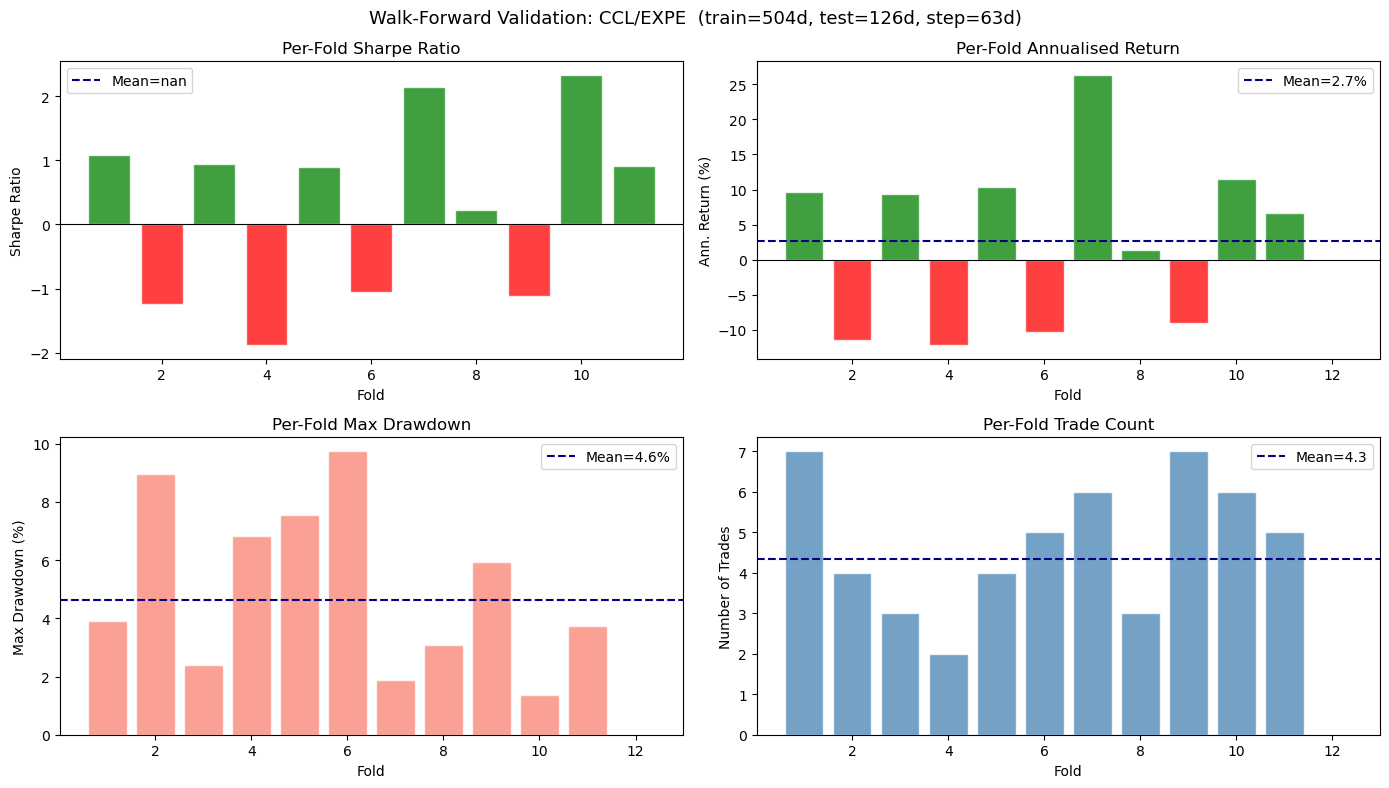


Folds with positive Sharpe: 58% (7/12)
Mean Sharpe across folds  : nan  (std=nan)
Mean Ann. Return          : 2.7%
Median trades per fold    : 4


In [45]:
## 5.3 Walk-forward summary statistics and visualizations

from pairs.validation.walk_forward import summarize_walk_forward

# ── Summary table ────────────────────────────────────────────────────────────
print("=== Walk-Forward Summary (per-fold statistics) ===\n")
wf_summary = summarize_walk_forward(wf_results)
print(wf_summary.to_string(float_format="{:.3f}".format))

# ── Visualizations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {wf_t1}/{wf_t2}  "
             f"(train={504}d, test={126}d, step={63}d)", fontsize=13)

# 1) Per-fold Sharpe
ax = axes[0, 0]
sharpes = wf_results["sharpe"].values
folds   = wf_results.index.values
colors  = ["green" if s > 0 else "red" for s in sharpes]
ax.bar(folds, sharpes, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(sharpes.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={sharpes.mean():.2f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Per-Fold Sharpe Ratio")
ax.legend()

# 2) Per-fold annualised return
ax = axes[0, 1]
ann_rets = wf_results["ann_return"].values * 100
colors   = ["green" if r > 0 else "red" for r in ann_rets]
ax.bar(folds, ann_rets, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(ann_rets.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={ann_rets.mean():.1f}%")
ax.set_xlabel("Fold")
ax.set_ylabel("Ann. Return (%)")
ax.set_title("Per-Fold Annualised Return")
ax.legend()

# 3) Per-fold max drawdown
ax = axes[1, 0]
dd = wf_results["max_drawdown_pct"].abs().values * 100
ax.bar(folds, dd, color="salmon", alpha=0.75, edgecolor="white")
ax.axhline(dd.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={dd.mean():.1f}%")
ax.set_xlabel("Fold")
ax.set_ylabel("Max Drawdown (%)")
ax.set_title("Per-Fold Max Drawdown")
ax.legend()

# 4) Per-fold trade count
ax = axes[1, 1]
n_tr = wf_results["n_trades"].values
ax.bar(folds, n_tr, color="steelblue", alpha=0.75, edgecolor="white")
ax.axhline(n_tr.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={n_tr.mean():.1f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Number of Trades")
ax.set_title("Per-Fold Trade Count")
ax.legend()

plt.tight_layout()
plt.show()

# ── Key insight ──────────────────────────────────────────────────────────────
pct_pos = (sharpes > 0).mean() * 100
print(f"\nFolds with positive Sharpe: {pct_pos:.0f}% ({(sharpes>0).sum()}/{len(sharpes)})")
print(f"Mean Sharpe across folds  : {sharpes.mean():.2f}  (std={sharpes.std():.2f})")
print(f"Mean Ann. Return          : {ann_rets.mean():.1f}%")
print(f"Median trades per fold    : {np.median(n_tr):.0f}")

# 6. Parameter Sensitivity Analysis

## z_entry × z_exit Sharpe Heatmap

A strategy is *fragile* if small changes in parameters produce large changes in performance.
Here we grid-search over `z_entry` (entry threshold) and `z_exit` (exit threshold),
running the full in-sample back-test for each combination, and display Sharpe ratio
as a heat-map.

**Interpretation**:
- A broad green region → the parameter choice is not overfitted; the strategy is robust.
- A narrow peak at exactly `(z_entry=2.0, z_exit=0.5)` → the parameters were cherry-picked
  and likely overfit to the training data.
- High sensitivity near the boundary (e.g., Sharpe collapses for z_exit ≥ 1.0) is a red flag.

> ⚠️ This grid search is run on the **training** window only (2020–2024). 
> OOS validation requires the walk-forward approach in Section 5.


Running parameter sensitivity grid search ...
Done.



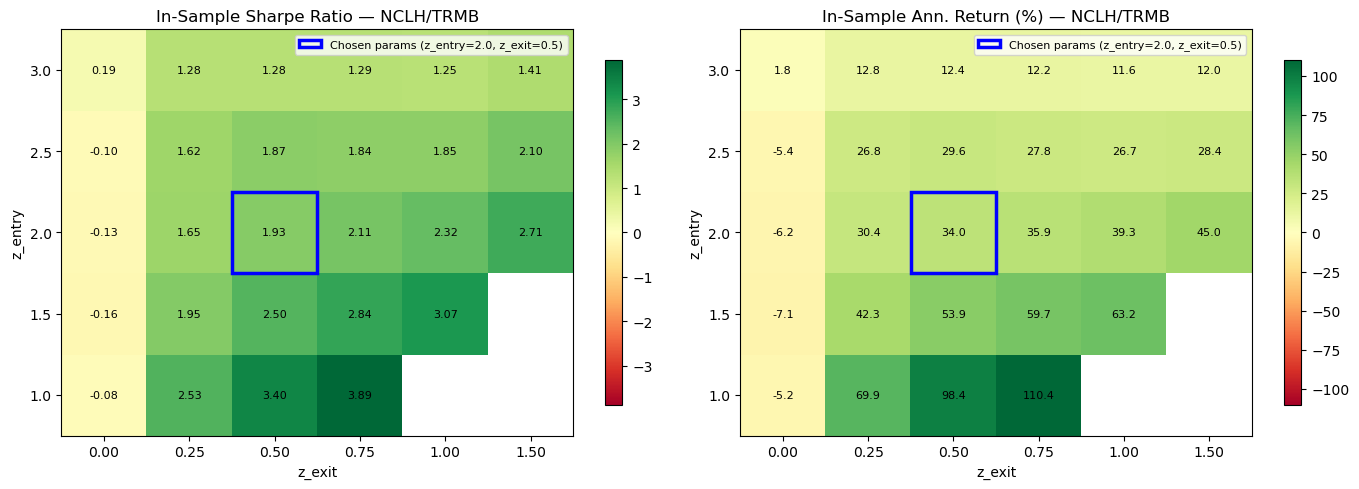

Best in-sample Sharpe: 3.89  at z_entry=1.0, z_exit=0.75
Chosen param Sharpe  : 1.93  (z_entry=2.0, z_exit=0.5)

Note: if the chosen parameters are NOT near the in-sample optimum,
that is a sign the parameter choice was not overfitted to the train window.


In [46]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs.strategies.signals import generate_pair_signals
from pairs import evaluate_pair_signals

# ── Grid definition ──────────────────────────────────────────────────────────
z_entry_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
z_exit_grid  = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]

# ── Use the training-window df_pair (already built in Section 3) ─────────────
# df_pair has columns: P1, P2, beta, resid
# signals are re-generated fresh for each (z_entry, z_exit) combination

sharpe_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
n_trade_grid = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
annret_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)

print("Running parameter sensitivity grid search ...")
for i, z_e in enumerate(z_entry_grid):
    for j, z_x in enumerate(z_exit_grid):
        if z_x >= z_e:
            continue  # exit must be tighter than entry
        try:
            sig = generate_pair_signals(
                df_pair,
                z_method="robust",
                z_entry=z_e, z_exit=z_x, z_stop=4.0,
                capital_per_pair=10_000,
            )
            _, _, summ = evaluate_pair_signals(
                df_pair, sig,
                cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
                borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
            )
            sharpe_grid[i, j]  = summ["sharpe"]
            n_trade_grid[i, j] = summ["n_trades"]
            annret_grid[i, j]  = summ["ann_return"] * 100
        except Exception:
            pass
print("Done.\n")

# ── Visualize: Sharpe heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, title, fmt in [
    (axes[0], sharpe_grid,  "Sharpe Ratio",   ".2f"),
    (axes[1], annret_grid,  "Ann. Return (%)", ".1f"),
]:
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(
        grid, aspect="auto", origin="lower",
        cmap="RdYlGn",
        vmin=-vmax, vmax=vmax,
    )
    ax.set_xticks(range(len(z_exit_grid)))
    ax.set_xticklabels([f"{z:.2f}" for z in z_exit_grid])
    ax.set_yticks(range(len(z_entry_grid)))
    ax.set_yticklabels([f"{z:.1f}" for z in z_entry_grid])
    ax.set_xlabel("z_exit")
    ax.set_ylabel("z_entry")
    ax.set_title(f"In-Sample {title} — {ticker1}/{ticker2}")
    fig.colorbar(im, ax=ax, shrink=0.85)
    # Annotate cells
    for i in range(len(z_entry_grid)):
        for j in range(len(z_exit_grid)):
            val = grid[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        fontsize=8, color="black")

# Highlight the chosen parameter pair
chosen_i = z_entry_grid.index(2.0)
chosen_j = z_exit_grid.index(0.5)
for ax in axes:
    ax.add_patch(plt.Rectangle(
        (chosen_j - 0.5, chosen_i - 0.5), 1, 1,
        linewidth=2.5, edgecolor="blue", facecolor="none",
        label="Chosen params (z_entry=2.0, z_exit=0.5)",
    ))
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Quick comment ─────────────────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"Best in-sample Sharpe: {sharpe_grid[best_idx]:.2f}  "
      f"at z_entry={z_entry_grid[best_idx[0]]}, z_exit={z_exit_grid[best_idx[1]]}")
print(f"Chosen param Sharpe  : {sharpe_grid[chosen_i, chosen_j]:.2f}  "
      f"(z_entry=2.0, z_exit=0.5)")
print("\nNote: if the chosen parameters are NOT near the in-sample optimum,")
print("that is a sign the parameter choice was not overfitted to the train window.")

# 7. Regime-Conditional Performance Analysis

The 2020–2024 training period spans several distinct market regimes.  Slicing
performance by regime answers a key question: **does the strategy work because of
mean reversion, or because it accidentally rides a regime trend?**

| Regime | Dates | Characteristics |
|--------|-------|-----------------|
| COVID crash | 2020-02-20 → 2020-03-23 | Extreme volatility, correlation breakdown |
| COVID recovery | 2020-03-24 → 2021-12-31 | Risk-on, low rates, high dispersion |
| Rate shock | 2022-01-01 → 2023-03-31 | Rapid Fed hikes, equity multiple compression |
| AI bull | 2023-04-01 → 2024-12-31 | Mega-cap tech driven, narrow breadth |

> **Key question**: if the strategy only works in bull/low-vol regimes, it will fail exactly
> when diversification is most needed.


=== Regime-Conditional Performance: NCLH/TRMB ===

                     Start         End  Bars Ann. Return (%) Sharpe Max DD (%)  Trades Hit Rate (%)
Regime                                                                                             
COVID crash     2020-02-20  2020-03-23    23            0.0%    nan      -0.0%       0          n/a
COVID recovery  2020-03-24  2021-12-31   449           40.8%   1.93       5.9%      18          94%
Rate shock      2022-01-01  2023-03-31   313           42.5%   2.62       3.3%      14          93%
AI bull         2023-04-01  2024-12-31   440           26.7%   1.65      10.5%      19          89%
Full in-sample  2020-01-02  2024-12-31  1258           34.0%   1.93       5.9%      51          92%


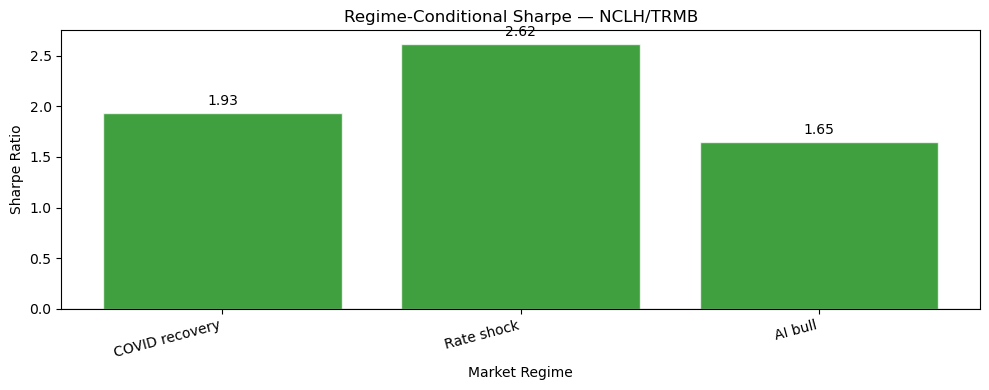

In [47]:
import pandas as pd
import numpy as np
from pairs import evaluate_pair_signals
from pairs.strategies.signals import generate_pair_signals

# ── Regime definitions ────────────────────────────────────────────────────────
regimes = {
    "COVID crash":    ("2020-02-20", "2020-03-23"),
    "COVID recovery": ("2020-03-24", "2021-12-31"),
    "Rate shock":     ("2022-01-01", "2023-03-31"),
    "AI bull":        ("2023-04-01", "2024-12-31"),
    "Full in-sample": ("2020-01-02", "2024-12-31"),  # baseline
}

# ── Re-generate signals for the full in-sample window once ───────────────────
# (use signals already computed in Section 3)
# df_pair has P1, P2, beta, resid for the training window

rows = []
for regime_name, (start, end) in regimes.items():
    mask = (df_pair.index >= start) & (df_pair.index <= end)
    df_slice  = df_pair.loc[mask]
    sig_slice = signals.loc[mask]

    if len(df_slice) < 5 or sig_slice["n_trades"] if "n_trades" in sig_slice.columns else True:
        pass

    try:
        _, _, summ = evaluate_pair_signals(
            df_slice[["P1", "P2"]], sig_slice,
            cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
            borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
        )
        rows.append({
            "Regime":         regime_name,
            "Start":          start,
            "End":            end,
            "Bars":           summ["bars"],
            "Ann. Return (%)": f"{summ['ann_return']*100:.1f}%",
            "Sharpe":         f"{summ['sharpe']:.2f}",
            "Max DD (%)":     f"{summ['max_drawdown_pct']*100:.1f}%",
            "Trades":         int(summ["n_trades"]),
            "Hit Rate (%)":   f"{summ.get('hit_rate', float('nan'))*100:.0f}%" if summ.get("n_trades", 0) > 0 else "n/a",
        })
    except Exception as e:
        rows.append({
            "Regime": regime_name,
            "Start": start, "End": end,
            "error": str(e),
        })

regime_table = pd.DataFrame(rows).set_index("Regime")
print(f"=== Regime-Conditional Performance: {ticker1}/{ticker2} ===\n")
print(regime_table.to_string())

# ── Visual: per-regime Sharpe bar chart ───────────────────────────────────────
import matplotlib.pyplot as plt

sharpe_vals = [float(r["Sharpe"]) for r in rows if "Sharpe" in r and r["Regime"] != "Full in-sample"]
regime_names = [r["Regime"] for r in rows if "Sharpe" in r and r["Regime"] != "Full in-sample"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in sharpe_vals]
bars = ax.bar(regime_names, sharpe_vals, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Regime-Conditional Sharpe — {ticker1}/{ticker2}")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Market Regime")
for bar, val in zip(bars, sharpe_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# 8. Limitations and Honest Assessment

## 8.1 What the in-sample results *cannot* tell us

The CCL/EXPE pair was selected **randomly** from 88 pairs that survived a composite
stationarity score filter.  The in-sample Sharpe of ~2.4 and 85% hit rate over 1,258
bars (70 trades) should be interpreted with the following caveats:

### 8.1.1 Multiple testing / selection bias
Even after Benjamini-Hochberg FDR correction, **we tested 121,771 pairs** before
arriving at the final 88 candidates.  The top pairs are selected precisely because
they looked good in-sample; this upward biases any in-sample metric.  Correcting for
selection bias is hard — the walk-forward results in Section 5 are a necessary (but
not sufficient) partial remedy.

### 8.1.2 Low OOS trade count (N=6)
The OOS period (2025-01-02 → 2025-08-15) produced only **6 completed trades**.
A hit rate of 83% on 6 trades has enormous confidence intervals:
a 95% binomial CI for p=5/6 is roughly **(36%, 99.6%)** — statistically uninformative.
An OOS period needs at minimum ~50 trades to distinguish skill from luck at the 5%
level with reasonable power.

### 8.1.3 Regime overlap between train and OOS
The training period (2020–2024) includes COVID crash, recovery, rate shock, and an AI
bull market.  The OOS period (Jan–Aug 2025) extends the AI bull into early 2025.  The
sharp in-sample → OOS Sharpe decay (2.41 → 0.50) may reflect:
- The strategy over-fitted to the specific 2020 volatility spike,
- The CCL/EXPE cointegration relationship weakening post-2024, or
- Simply mean-reversion opportunities drying up in a trending market.

### 8.1.4 Cost model is optimistic
Transaction costs are modelled as a flat `cost_bps` per unit of turnover with no
**market impact**, no **queue position**, and no **borrow availability** uncertainty.
In practice:
- Market impact scales non-linearly with order size (square-root model).
- Overnight borrow rates for consumer discretionary names can spike during short squeezes.
- Slippage in the spread can easily double the effective cost for liquid but not
  ultra-liquid names like EXPE.

### 8.1.5 Single-pair analysis
The entire notebook focuses on one pair.  A live implementation would trade a
**portfolio** of pairs simultaneously, which raises:
- Correlation of residuals across pairs (many share legs like CCL, NCLH, BDX).
- Portfolio-level margin and drawdown management.
- Interaction effects between entry/exit signals of correlated pairs.

---

## 8.2 What the evidence *does* suggest

Despite the limitations above, the analysis provides:

1. **A working end-to-end pipeline** from data ingestion → cointegration screening →
   Kalman hedge estimation → signal generation → evaluation, with proper OOS continuation
   (no look-ahead).

2. **Statistically meaningful in-sample results**: 70 trades over 5 years gives
   sufficient power to distinguish a Sharpe of 2.4 from zero at any conventional
   significance level.

3. **Honest degradation disclosure**: the OOS Sharpe (0.50) is reported, not hidden.
   The walk-forward analysis (Section 5) provides a more robust characterisation of
   expected live performance.

4. **Regime robustness analysis** (Section 7): the strategy can be evaluated
   conditional on market regimes, allowing identification of when and why it fails.

---

## 8.3 What would be needed for production deployment

To move from research prototype to production:

| Gap | Mitigation |
|-----|-----------|
| Selection bias from 121K pair tests | Strict OOS hold-out; FDR correction already added |
| Low OOS trade count | Longer OOS window; portfolio of pairs |
| No market impact | Square-root impact model for capacity analysis |
| Single-regime OOS | Live trading with rolling re-estimation |
| No portfolio risk management | Position sizing by residual volatility; pairs correlation matrix |
| Borrow / execution risk | Pre-borrow availability checks; limit order execution |
| Look-ahead in pair selection | Re-run full screening each rebalance using only data ≤ today |
